In [2]:
import sys
sys.path.insert(0, '../')

import matplotlib.pyplot as plt
import pyflubl
import test_T004_Quad
import uproot
import numpy
import awkward as ak

initializing ocelot...


In [3]:
m = test_T004_Quad.make_quad(offsetY=1)
d = pyflubl.Analysis.openFile("./T004_Quad_offsetY001_dump","usrdump")

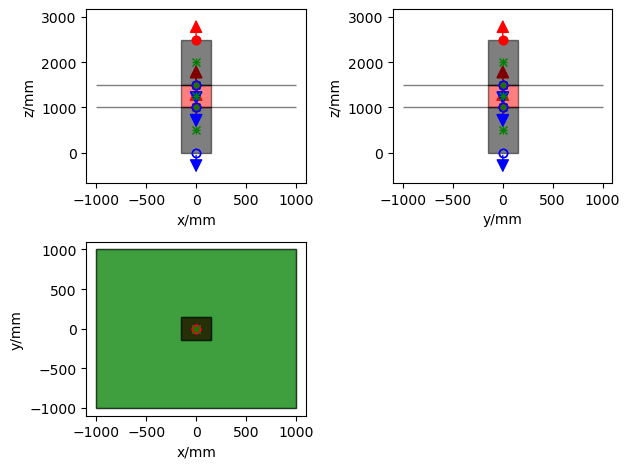

In [4]:
pyflubl.Analysis.plot_coordinates(m)

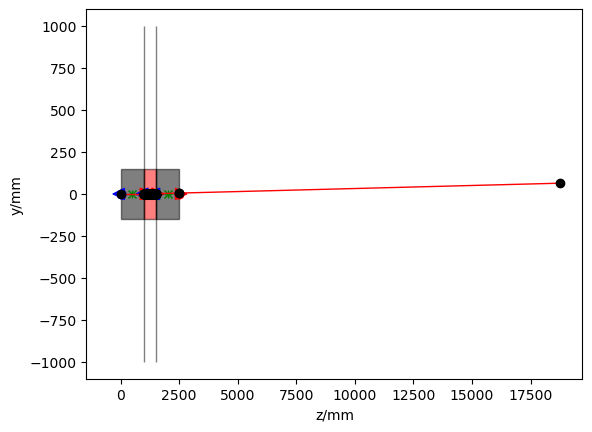

In [6]:
d.read_event(0)
pyflubl.Analysis.plot_coordinates_projection(m,"zy")
pyflubl.Analysis.plot_usrdump(d,"zy")

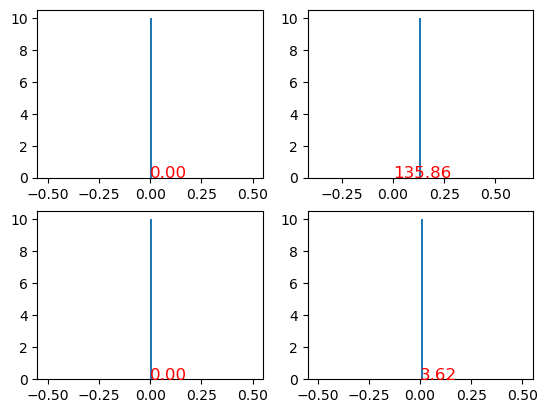

In [8]:
bk = pyflubl.Analysis.openBookkeepingFile("./pyflubl.json")
list(bk['samplernames_samplernumber'].keys())

trees = [uproot.open(f)["event"] for f in ["T004_Quad_offsetY001_pyflubl.root"]]

arrays = [tree["s2.x"].array() for tree in trees]
s5_x_all = numpy.ravel(ak.concatenate(arrays))

arrays = [tree["s2.y"].array() for tree in trees]
s5_y_all = numpy.ravel(ak.concatenate(arrays))

arrays = [tree["s2.xp"].array() for tree in trees]
s5_xp_all = numpy.ravel(ak.concatenate(arrays))

arrays = [tree["s2.yp"].array() for tree in trees]
s5_yp_all = numpy.ravel(ak.concatenate(arrays))

plt.subplot(2,2,1)
plt.hist(s5_x_all,100);
plt.text(0, 0, f'{numpy.array(s5_x_all).mean()*1000:.2f}', fontsize=12, color='red');

plt.subplot(2,2,2)
plt.hist(s5_y_all,100);
plt.text(0, 0, f'{numpy.array(s5_y_all).mean()*1000:.2f}', fontsize=12, color='red');

plt.subplot(2,2,3)
plt.hist(s5_xp_all,100);
plt.text(0, 0, f'{numpy.array(s5_xp_all).mean()*1000:.2f}', fontsize=12, color='red');

plt.subplot(2,2,4)
plt.hist(s5_yp_all,100);
plt.text(0, 0, f'{numpy.array(s5_yp_all).mean()*1000:.2f}', fontsize=12, color='red');